In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, roc_auc_score, roc_curve, classification_report
)
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('Titanic Dataset.csv')
print(df.shape)
df.head()

(1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


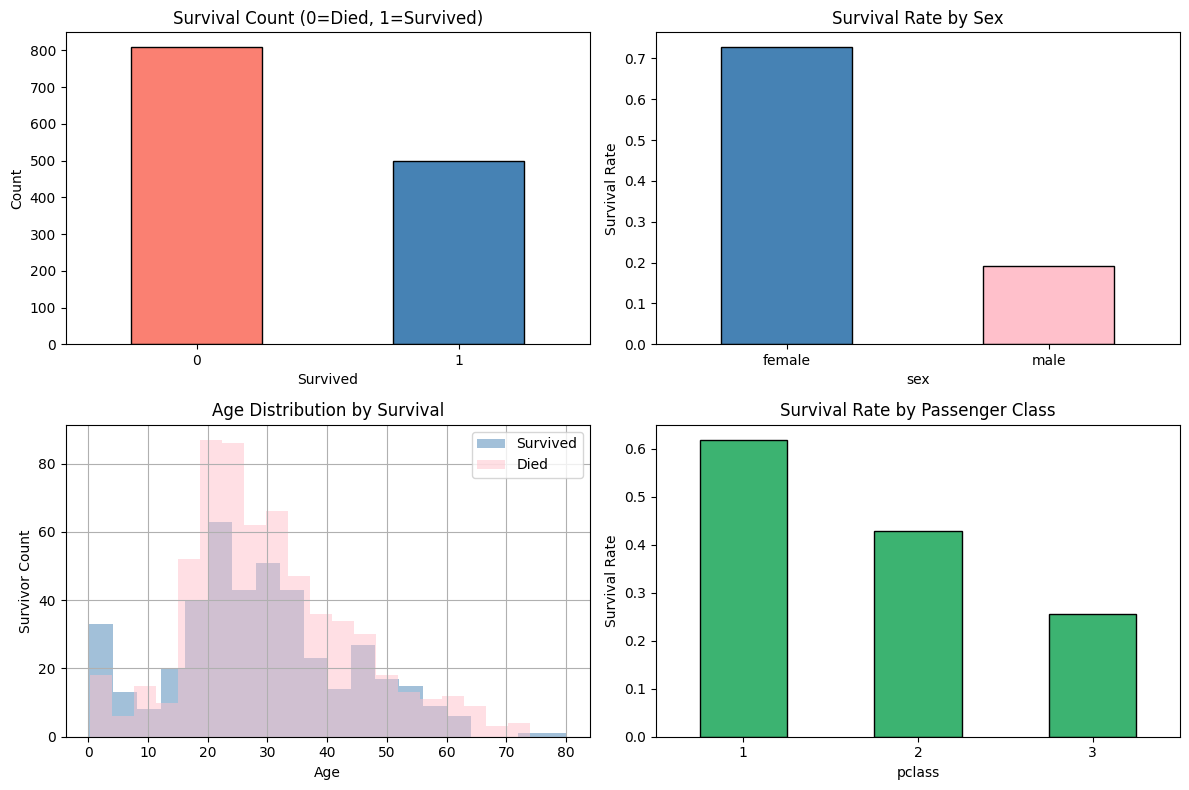

In [137]:
1.
#

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Graph 1: Survival count
df['survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['salmon','steelblue'], edgecolor='black')
axes[0,0].set_title('Survival Count (0=Died, 1=Survived)')
axes[0,0].set_xlabel('Survived')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(rotation=0)

# Graph 2: Survival by sex
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,1], color=['steelblue','pink'], edgecolor='black')
axes[0,1].set_title('Survival Rate by Sex')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].tick_params(rotation=0)

# Graph 3: Age distribution by survival
df[df['survived']==1]['age'].dropna().hist(ax=axes[1,0], bins=20, alpha=0.5, color='steelblue', label='Survived')
df[df['survived']==0]['age'].dropna().hist(ax=axes[1,0], bins=20, alpha=0.5, color='pink', label='Died')
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Survivor Count')
axes[1,0].legend()

# Graph 4: Survival rate by pclass
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1,1], color='mediumseagreen', edgecolor='black')
axes[1,1].set_title('Survival Rate by Passenger Class')
axes[1,1].set_ylabel('Survival Rate')
axes[1,1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [139]:
# missing values & encode categoricals
df['age'] = df['age'].fillna(df['age'].median())   # fill missing age with the median age?
df['sex'] = df['sex'].map({'male': 0, 'female': 1}) # encode sex with binary

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
df = df.dropna(subset=features + ['survived'])      # drop rows missing key features

X = df[features]
y = df['survived']
print(f"Dataset size after cleaning: {X.shape}")


Dataset size after cleaning: (1308, 6)


In [141]:
2.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# random state = 10 produces the exact same training and test data every time, so we can compare each run effectively

Train: 1046 rows | Test: 262 rows


In [143]:
3.
dt = DecisionTreeClassifier(random_state=10)
dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  dt.predict(X_test))
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

# The model has overfit, and memorized the training set passengers' noise and now can't generalize to the test dataset of passengers

Training accuracy: 0.9656
Test accuracy:  0.7557


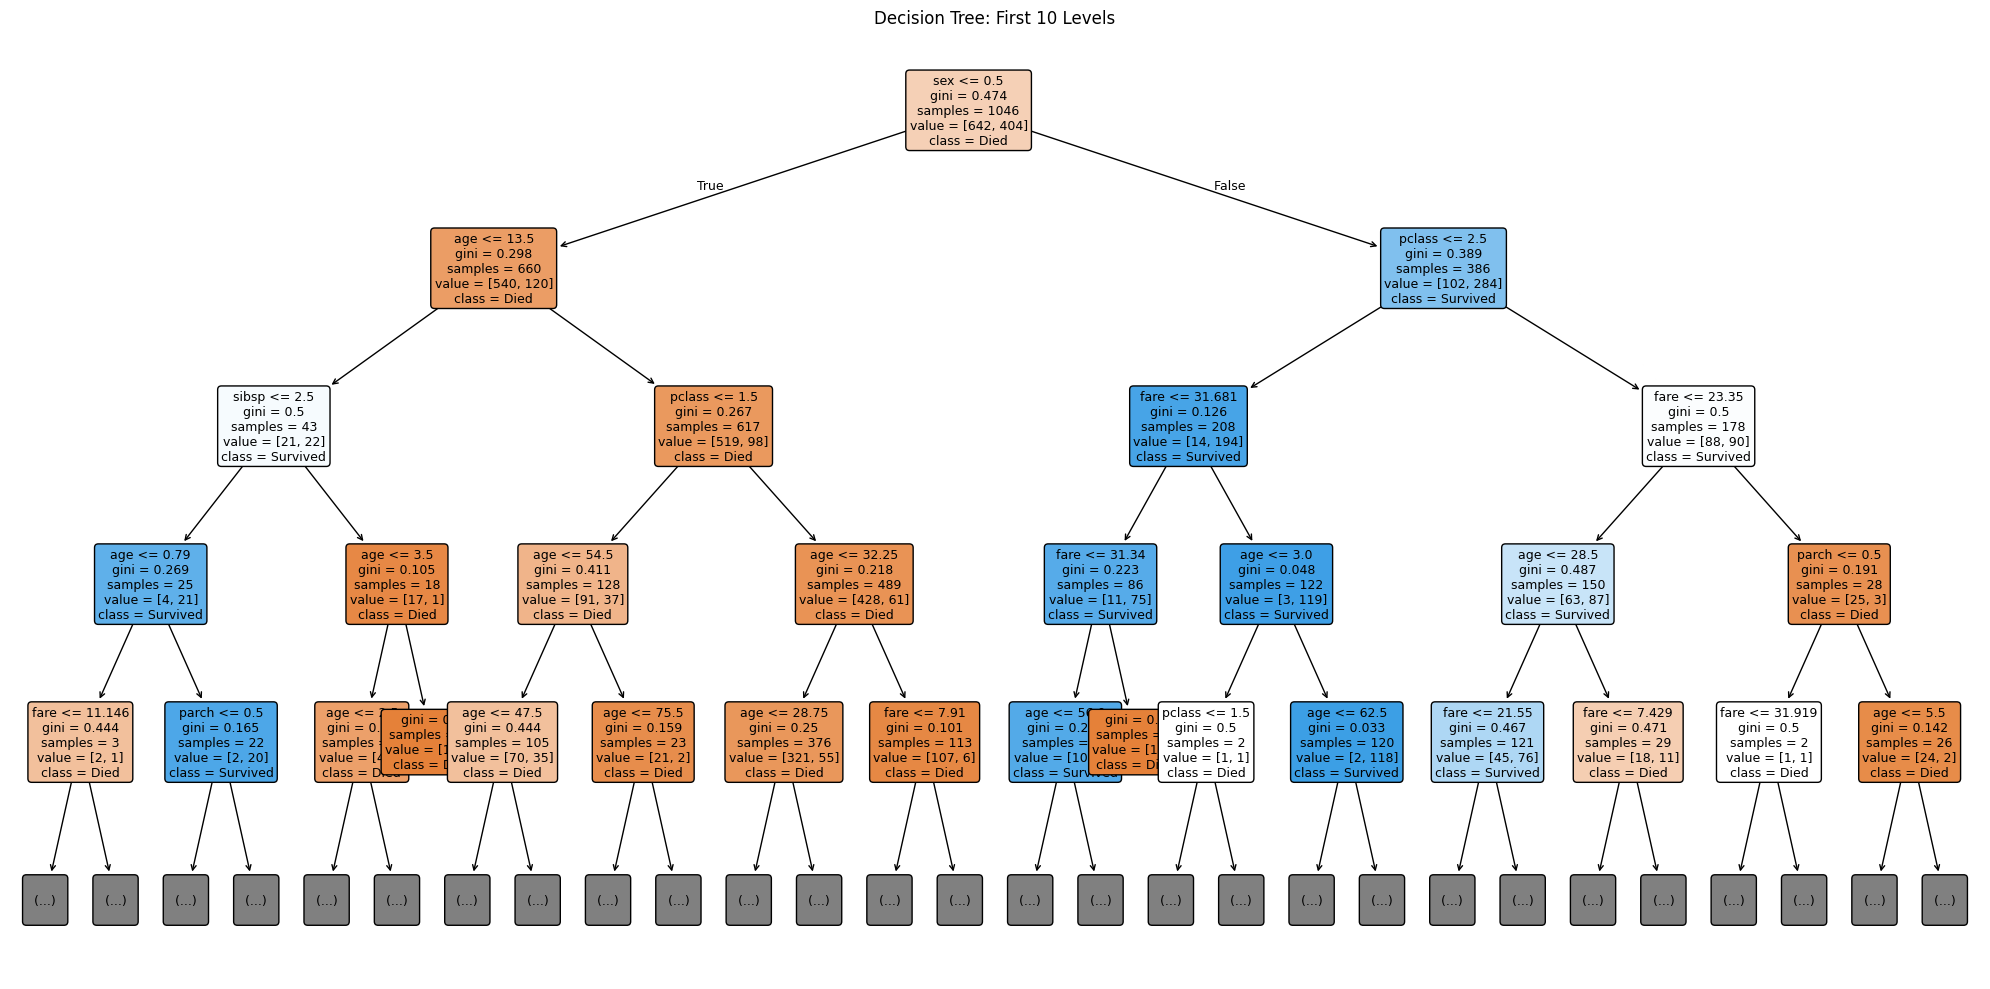

Root split feature: sex


In [145]:
4.
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=4, feature_names=features, class_names=['Died','Survived'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree: First 10 Levels')
plt.tight_layout()
plt.show()
print(f"Root split feature: {features[dt.tree_.feature[0]]}")

# The root node split based on sex, which makes sense given our data visualization showed the clarest split in survival rates was sex
# Intuitively, this makes sense because children and women are always evacuated first in an emergency like the Titanic

In [177]:
5.
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=10)
dt_pruned.fit(X_train, y_train)

print(f"Pruned tree test accuracy:  {accuracy_score(y_test, dt_pruned.predict(X_test)):.4f}")
print(f"Deep tree  test accuracy:   {test_acc:.4f}")

# Limiting the depth made the model learn the most basic generalized rules for classifying passengers, so it reduced overfitting that way
# Therefore our accuracy improved a little bit

Pruned tree test accuracy:  0.7824
Deep tree  test accuracy:   0.7557


In [149]:
6.
rf = RandomForestClassifier(n_estimators=100, random_state=10)
rf.fit(X_train, y_train)
print(f"Random Forest test accuracy: {accuracy_score(y_test, rf.predict(X_test)):.3f}")

# Each of my 100 trees is based on a random sample of the passengers and considers random features every split, and the overall forest 
# will predict by majority consensus across trees. This should cancel out any small tree errors and reduce overfitting

Random Forest test accuracy: 0.794


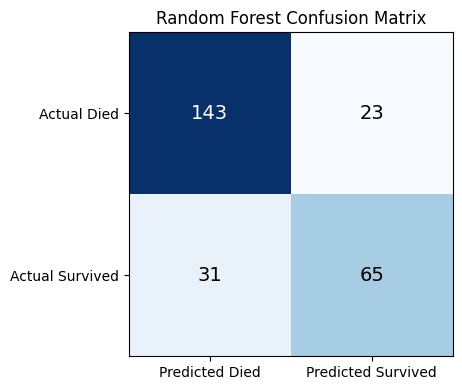

False Positives (predicted survived, actually died): 23
False Negatives (predicted died, actually survived): 31


In [151]:
7.
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted Died','Predicted Survived'])
ax.set_yticklabels(['Actual Died','Actual Survived'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False Positives (predicted survived, actually died): {fp}")
print(f"False Negatives (predicted died, actually survived): {fn}")

In [153]:
8.
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")

# I would want to maximize recall, because catching every true survivor at the cost of a few false alarms is worth it

Precision: 0.739
Recall:    0.677


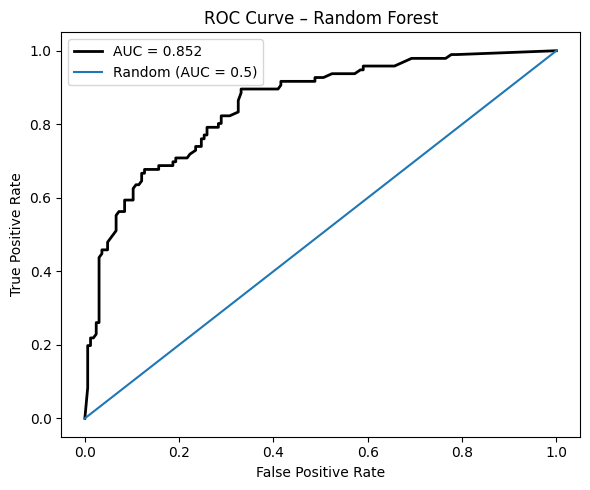

AUC: 0.852


In [155]:
9.
y_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='black', lw=2)
plt.plot([0,1],[0,1], label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.tight_layout()
plt.show()
print(f"AUC: {auc:.3f}")

# The AUC of about 0.85 means we correctly predict a random survivor vs. a random death 85% of the time, so it separates them well

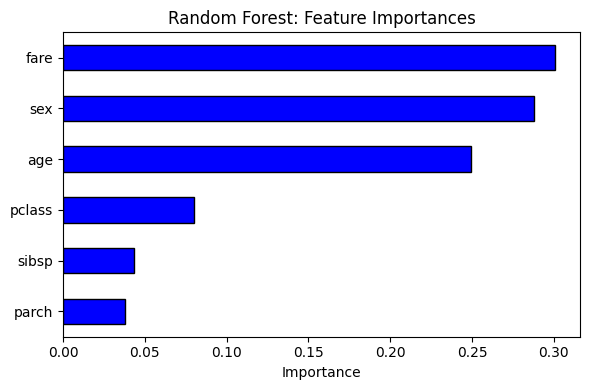

fare      0.300938
sex       0.287993
age       0.249349
pclass    0.080316
sibsp     0.043386
parch     0.038018
dtype: float64


In [89]:
10.
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(6, 4))
importances.plot(kind='barh', color='blue', edgecolor='black')
plt.title('Random Forest: Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

# The most influential features were fare, sex, and age. Number of siblings/spouses aboard, number of parents/children aboard, and class
# were not so important. Nothing was COMPLETELY useless though

In [165]:
# W8 Extension Work:
1.
y_death = 1 - y

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_death, test_size=0.2, random_state=10
)

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

model1 = GridSearchCV(
    LogisticRegression(solver='liblinear', max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)
model1.fit(X_train2, y_train2)

print(f"Best params: {model1.best_params_}")
print(f"Best CV AUC: {model1.best_score_:.3f}")

Best params: {'C': 0.1, 'penalty': 'l2'}
Best CV AUC: 0.844


In [167]:
2.
print(f"Best penalty: {model1.best_params_['penalty']}")

# L2 was the better penalty. This makes sense because all features in the Titanic dataset have real predicting ability for survival.
# L1 would be better if the dataset had a ton of noise and useless variables

Best penalty: l2


In [169]:
3.
print(f"Best C: {model1.best_params_['C']}")

# This C-value of 0.1 shows an increase inr regularization, which will make the model less sensitive to each point
# This will reduce overfitting and allow it generalize better 

weak regularization, so its placing less penalty on higher weighted features

Best C: 0.1


              precision    recall  f1-score   support

    Survived       0.69      0.55      0.61        96
        Died       0.77      0.86      0.81       166

    accuracy                           0.74       262
   macro avg       0.73      0.70      0.71       262
weighted avg       0.74      0.74      0.74       262

AUC: 0.803


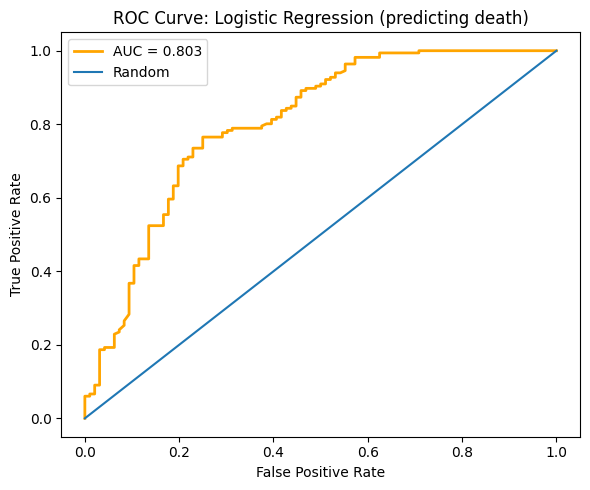

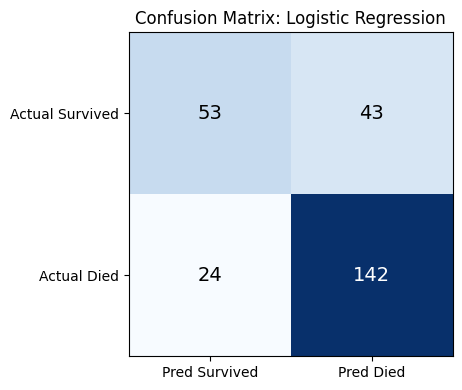

In [175]:
4.
best_lr = model1.best_estimator_
y_pred2   = best_lr.predict(X_test2)
y_proba2  = best_lr.predict_proba(X_test2)[:, 1]

print(classification_report(y_test2, y_pred2, target_names=['Survived','Died']))
print(f"AUC: {roc_auc_score(y_test2, y_proba2):.3f}")

# ROC Curve
fpr2, tpr2, _ = roc_curve(y_test2, y_proba2)
plt.figure(figsize=(6, 5))
plt.plot(fpr2, tpr2, color='orange', lw=2, label=f'AUC = {roc_auc_score(y_test2, y_proba2):.3f}')
plt.plot([0,1],[0,1], label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression (predicting death)')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix
cm2 = confusion_matrix(y_test2, y_pred2)
fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(cm2, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Survived','Pred Died'])
ax.set_yticklabels(['Actual Survived','Actual Died'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm2[i,j], ha='center', va='center', fontsize=14,
                color='white' if cm2[i,j] > cm2.max()/2 else 'black')
ax.set_title('Confusion Matrix: Logistic Regression')
plt.tight_layout()
plt.show()

# The most appropriate metric is recall for the 'died' class, because minimizing this will allow us to provide the highest quality
# survivor data to families. Our recall is 0.86 for this class, so this is very good and minimizes false positives

5.
No, linear regression is not appropriate because death is a binary decision, so logistic regression will be best for predicting this binary outcome and providing probabilities. Linear regression would make no sense.